In [1]:
# ============================================================
# CELL 1: Install kagglehub (run once)
# ============================================================
!pip install kagglehub -q

In [2]:
# ============================================================
# CELL 2: Import Libraries
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time
from pathlib import Path

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [3]:
# ============================================================
# CELL 3: Download PaySim Dataset from Kaggle (auto-download)
# ============================================================
# First time: it will ask you to authenticate with Kaggle
# Follow the instructions in the output
# After first download, it caches - so next runs are instant

import kagglehub

print("Downloading PaySim dataset from Kaggle...")
print("(First run: ~2 min download | After that: cached)")

path = kagglehub.dataset_download("ealaxi/paysim1")
print(f"Downloaded to: {path}")

# Find the CSV file automatically
csv_files = list(Path(path).glob("*.csv"))
assert len(csv_files) > 0, "No CSV found! Check the download."
CSV_PATH = csv_files[0]
print(f"CSV file found: {CSV_PATH.name}")

(First run: ~2 min download | After that: cached)
Using Colab cache for faster access to the 'paysim1' dataset.
Downloaded to: /kaggle/input/paysim1
CSV file found: PS_20174392719_1491204439457_log.csv


In [4]:
# ============================================================
# CELL 4: Load the Dataset
# ============================================================
print("Loading PaySim dataset... (this may take 1-2 minutes)")
t0 = time.time()
df = pd.read_csv(CSV_PATH)
elapsed = time.time() - t0

print()
print("=" * 55)
print(f"  Total Rows    : {len(df):,}")
print(f"  Total Columns : {len(df.columns)}")
print(f"  Loaded in     : {elapsed:.1f}s")
print("=" * 55)

print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst 5 rows:")
df.head()

Loading PaySim dataset... (this may take 1-2 minutes)

  Total Rows    : 6,362,620
  Total Columns : 11
  Loaded in     : 14.5s

Columns: ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']

First 5 rows:


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [5]:
# ============================================================
# CELL 5: Dataset Overview
# ============================================================
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print(f"\nTransaction Types:")
print(df['type'].value_counts())

print(f"\nFraud Distribution:")
print(df['isFraud'].value_counts())
print(f"\nFraud Rate: {df['isFraud'].mean()*100:.4f}%")

print(f"\nFraud by Transaction Type:")
fraud_by_type = df.groupby('type')['isFraud'].agg(['sum', 'count', 'mean'])
fraud_by_type.columns = ['Fraud Count', 'Total Count', 'Fraud Rate']
fraud_by_type['Fraud Rate'] = fraud_by_type['Fraud Rate'].apply(lambda x: f"{x*100:.4f}%")
print(fraud_by_type)

DATASET OVERVIEW

Transaction Types:
type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

Fraud Distribution:
isFraud
0    6354407
1       8213
Name: count, dtype: int64

Fraud Rate: 0.1291%

Fraud by Transaction Type:
          Fraud Count  Total Count Fraud Rate
type                                         
CASH_IN             0      1399284    0.0000%
CASH_OUT         4116      2237500    0.1840%
DEBIT               0        41432    0.0000%
PAYMENT             0      2151495    0.0000%
TRANSFER         4097       532909    0.7688%


In [6]:
# ============================================================
# CELL 6: Feature Engineering - 8 Behavioral Features
# ============================================================
print("=" * 60)
print("FEATURE ENGINEERING (8 Features)")
print("=" * 60)

# F1: Log Amount - magnitude normalization
df['F1_log_amount'] = np.log1p(df['amount'])

# F2: Amount-to-Balance Ratio - account draining detection
df['F2_amount_balance_ratio'] = df['amount'] / (df['oldbalanceOrg'] + 1)

# F3: Balance Consistency Score - math consistency check
df['F3_balance_consistency'] = (
    np.abs(df['oldbalanceOrg'] - df['amount'] - df['newbalanceOrig']) < 0.01
).astype(int)

# F4: Balance Change Ratio - proportional impact
df['F4_balance_change_ratio'] = (
    (df['newbalanceOrig'] - df['oldbalanceOrg']) / (df['oldbalanceOrg'] + 1)
)

# F5: Destination Balance Ratio - mule account detection
df['F5_dest_balance_ratio'] = df['newbalanceDest'] / (df['oldbalanceDest'] + 1)

# F6: Hour of Day - temporal pattern (normalized 0-1)
df['F6_hour'] = (df['step'] % 24) / 24

# F7: Day of Simulation - periodic pattern (normalized 0-1)
df['F7_day'] = (df['step'] / 24) / 30

# F8: Is Large Transaction - type-relative P95 outlier
# FIX 1: Compute P95 on NORMAL transactions only (avoid fraud leakage into threshold)
# FIX 2: Use vectorized .map() instead of df.apply (10 min -> <1 sec on 6.3M rows)
p95_by_type = df[df['isFraud'] == 0].groupby('type')['amount'].quantile(0.95)
df['F8_is_large'] = (df['amount'] > df['type'].map(p95_by_type)).astype(int)

feature_cols = ['F1_log_amount', 'F2_amount_balance_ratio', 'F3_balance_consistency',
                'F4_balance_change_ratio', 'F5_dest_balance_ratio', 'F6_hour',
                'F7_day', 'F8_is_large']

print("\nAll 8 features computed successfully!")
print(f"\nFeature Statistics:")
print(df[feature_cols].describe().round(4))

FEATURE ENGINEERING (8 Features)

All 8 features computed successfully!

Feature Statistics:
       F1_log_amount  F2_amount_balance_ratio  F3_balance_consistency  \
count   6.362620e+06             6.362620e+06            6.362620e+06   
mean    1.084090e+01             7.067448e+04            2.019000e-01   
std     1.814500e+00             5.084243e+05            4.015000e-01   
min     0.000000e+00             0.000000e+00            0.000000e+00   
25%     9.502300e+00             2.344000e-01            0.000000e+00   
50%     1.122350e+01             6.453800e+00            0.000000e+00   
75%     1.224880e+01             1.228776e+04            0.000000e+00   
max     1.834210e+01             9.244552e+07            1.000000e+00   

       F4_balance_change_ratio  F5_dest_balance_ratio       F6_hour  \
count             6.362620e+06           6.362620e+06  6.362620e+06   
mean              3.847390e+02           1.960735e+04  6.384000e-01   
std               9.987308e+03      

In [7]:
# ============================================================
# CELL 7: Stratification by Transaction Type
# ============================================================
print("=" * 60)
print("STRATIFICATION BY TRANSACTION TYPE")
print("=" * 60)

types_to_keep = ['TRANSFER', 'CASH_OUT', 'PAYMENT']
df_stratified = df[df['type'].isin(types_to_keep)].copy()

print(f"\nFiltered to {len(df_stratified):,} transactions (TRANSFER + CASH_OUT + PAYMENT)")

for txn_type in types_to_keep:
    subset = df_stratified[df_stratified['type'] == txn_type]
    fraud_count = subset['isFraud'].sum()
    normal_count = len(subset) - fraud_count
    print(f"\n  {txn_type}:")
    print(f"    Total:      {len(subset):,}")
    print(f"    Normal:     {normal_count:,}")
    print(f"    Fraud:      {fraud_count:,}")
    if len(subset) > 0:
        print(f"    Fraud Rate: {fraud_count/len(subset)*100:.4f}%")

STRATIFICATION BY TRANSACTION TYPE

Filtered to 4,921,904 transactions (TRANSFER + CASH_OUT + PAYMENT)

  TRANSFER:
    Total:      532,909
    Normal:     528,812
    Fraud:      4,097
    Fraud Rate: 0.7688%

  CASH_OUT:
    Total:      2,237,500
    Normal:     2,233,384
    Fraud:      4,116
    Fraud Rate: 0.1840%

  PAYMENT:
    Total:      2,151,495
    Normal:     2,151,495
    Fraud:      0
    Fraud Rate: 0.0000%


In [8]:
# ============================================================
# CELL 8: F3 Dominance Analysis
# ============================================================
print("=" * 60)
print("F3 (BALANCE CONSISTENCY) DOMINANCE ANALYSIS")
print("=" * 60)

fraud_txns = df_stratified[df_stratified['isFraud'] == 1]
normal_txns = df_stratified[df_stratified['isFraud'] == 0]

fraud_f3_zero = (fraud_txns['F3_balance_consistency'] == 0).sum()
fraud_f3_one = (fraud_txns['F3_balance_consistency'] == 1).sum()
normal_f3_zero = (normal_txns['F3_balance_consistency'] == 0).sum()
normal_f3_one = (normal_txns['F3_balance_consistency'] == 1).sum()

print(f"\nFraud transactions:")
print(f"  F3=0 (balances DON'T add up): {fraud_f3_zero} / {len(fraud_txns)} ({fraud_f3_zero/len(fraud_txns)*100:.1f}%)")
print(f"  F3=1 (balances DO add up):    {fraud_f3_one} / {len(fraud_txns)} ({fraud_f3_one/len(fraud_txns)*100:.1f}%)")

print(f"\nNormal transactions:")
print(f"  F3=0 (balances DON'T add up): {normal_f3_zero} / {len(normal_txns)} ({normal_f3_zero/len(normal_txns)*100:.1f}%)")
print(f"  F3=1 (balances DO add up):    {normal_f3_one} / {len(normal_txns)} ({normal_f3_one/len(normal_txns)*100:.1f}%)")

if len(fraud_txns) > 0 and fraud_f3_zero / len(fraud_txns) > 0.9:
    print("\n⚠️  WARNING: F3 alone catches >90% of fraud!")
    print("   This confirms the need for the feature necessity analysis")
    print("   (Configurations E, F, G in the ablation study)")

F3 (BALANCE CONSISTENCY) DOMINANCE ANALYSIS

Fraud transactions:
  F3=0 (balances DON'T add up): 45 / 8213 (0.5%)
  F3=1 (balances DO add up):    8168 / 8213 (99.5%)

Normal transactions:
  F3=0 (balances DON'T add up): 3665901 / 4913691 (74.6%)
  F3=1 (balances DO add up):    1247790 / 4913691 (25.4%)


In [9]:
# ============================================================
# CELL 9: Feature Comparison - Fraud vs Normal
# ============================================================
print("=" * 60)
print("FEATURE COMPARISON: FRAUD vs NORMAL")
print("=" * 60)

for txn_type in ['TRANSFER', 'CASH_OUT']:
    subset = df_stratified[df_stratified['type'] == txn_type]
    fraud = subset[subset['isFraud'] == 1][feature_cols]
    normal = subset[subset['isFraud'] == 0][feature_cols]

    print(f"\n--- {txn_type} ---")
    print(f"{'Feature':<30} {'Normal Mean':>12} {'Fraud Mean':>12} {'Difference':>12}")
    print("-" * 70)
    for col in feature_cols:
        n_mean = normal[col].mean()
        f_mean = fraud[col].mean()
        diff = f_mean - n_mean
        print(f"{col:<30} {n_mean:>12.4f} {f_mean:>12.4f} {diff:>12.4f}")


FEATURE COMPARISON: FRAUD vs NORMAL

--- TRANSFER ---
Feature                         Normal Mean   Fraud Mean   Difference
----------------------------------------------------------------------
F1_log_amount                       12.9702      12.9243      -0.0459
F2_amount_balance_ratio         498630.5947    1126.3844 -497504.2103
F3_balance_consistency               0.0379       0.9949       0.9570
F4_balance_change_ratio             -0.4441      -0.9811      -0.5370
F5_dest_balance_ratio           115937.8066    1997.2042 -113940.6024
F6_hour                              0.6347       0.4809      -0.1538
F7_day                               0.3413       0.5127       0.1714
F8_is_large                          0.0500       0.1621       0.1121

--- CASH_OUT ---
Feature                         Normal Mean   Fraud Mean   Difference
----------------------------------------------------------------------
F1_log_amount                       11.6774      12.8599       1.1824
F2_amount_balanc

GENERATING VISUALIZATIONS
Mounted at /content/drive


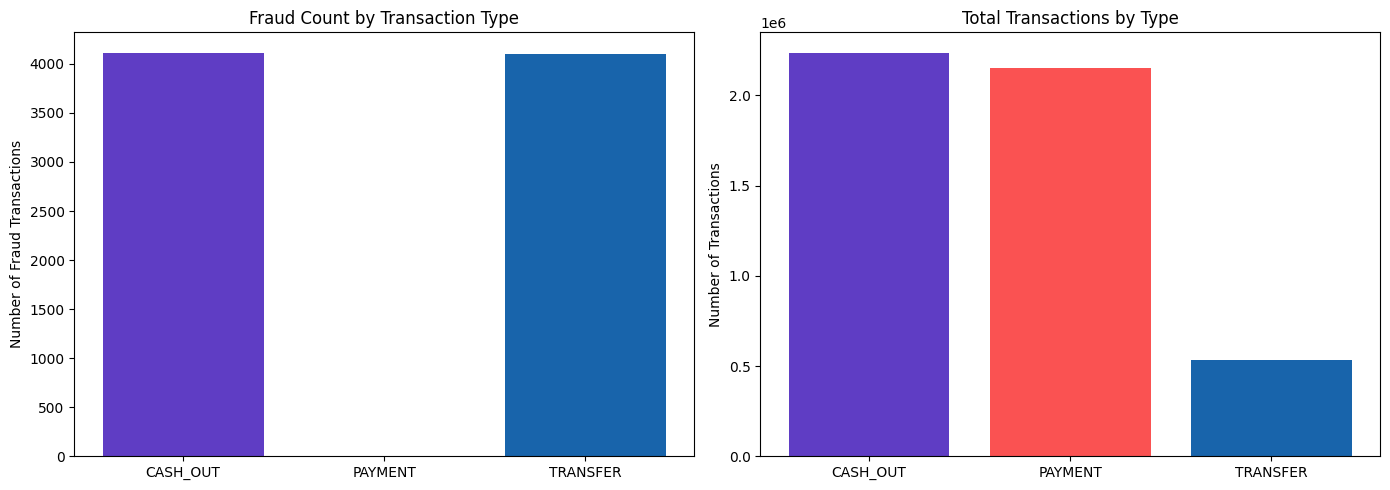

Saved: fraud_by_type.png


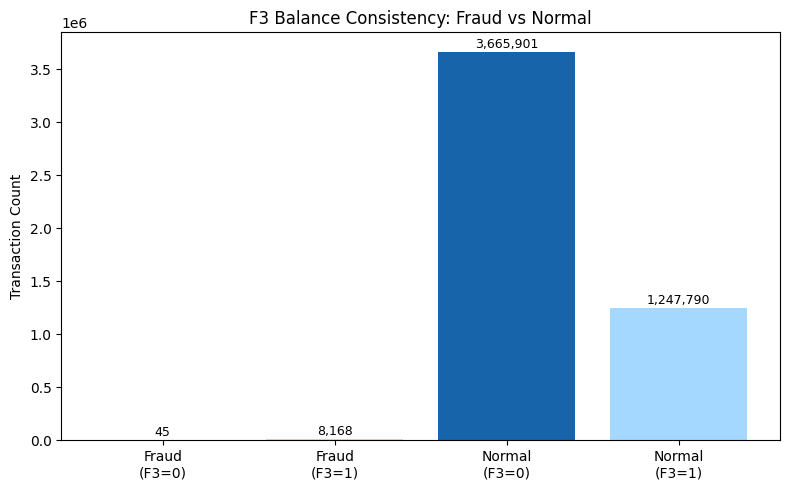

Saved: f3_analysis.png


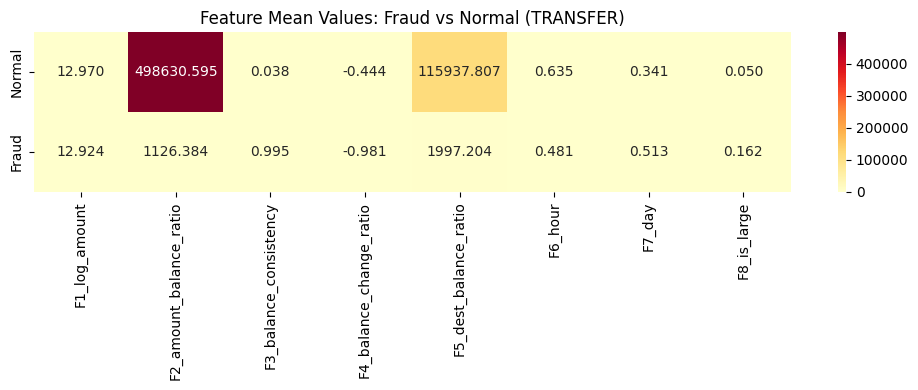

Saved: feature_heatmap_transfer.png


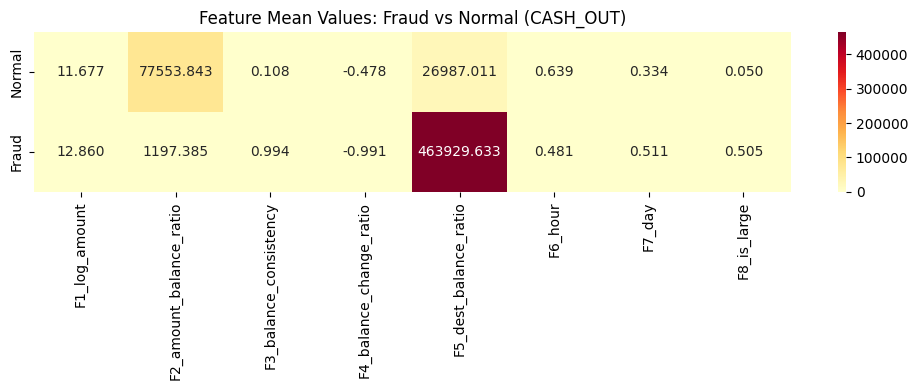

Saved: feature_heatmap_cashout.png


In [10]:
# ============================================================
# CELL 10: Visualizations
# ============================================================
print("=" * 60)
print("GENERATING VISUALIZATIONS")
print("=" * 60)

# Mount Google Drive and set output folder
from google.colab import drive
drive.mount('/content/drive')
output_dir = '/content/drive/MyDrive/DeepSentinel/DeepSentinel_Output'
os.makedirs(output_dir, exist_ok=True)

# Plot 1: Fraud distribution by type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fraud_counts = df_stratified.groupby('type')['isFraud'].sum()
axes[0].bar(fraud_counts.index, fraud_counts.values, color=['#5f3dc4', '#fa5252', '#1864ab'])
axes[0].set_title('Fraud Count by Transaction Type')
axes[0].set_ylabel('Number of Fraud Transactions')

type_counts = df_stratified['type'].value_counts()
axes[1].bar(type_counts.index, type_counts.values, color=['#5f3dc4', '#fa5252', '#1864ab'])
axes[1].set_title('Total Transactions by Type')
axes[1].set_ylabel('Number of Transactions')

plt.tight_layout()
plt.savefig(f'{output_dir}/fraud_by_type.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fraud_by_type.png")

# Plot 2: F3 Balance Consistency - Fraud vs Normal
fig, ax = plt.subplots(figsize=(8, 5))
categories = ['Fraud\n(F3=0)', 'Fraud\n(F3=1)', 'Normal\n(F3=0)', 'Normal\n(F3=1)']
values = [fraud_f3_zero, fraud_f3_one, normal_f3_zero, normal_f3_one]
colors = ['#fa5252', '#ffc9c9', '#1864ab', '#a5d8ff']
ax.bar(categories, values, color=colors)
ax.set_title('F3 Balance Consistency: Fraud vs Normal')
ax.set_ylabel('Transaction Count')
for i, v in enumerate(values):
    ax.text(i, v + max(values)*0.01, f'{v:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(f'{output_dir}/f3_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: f3_analysis.png")

# Plot 3: Feature heatmap - TRANSFER
fig, ax = plt.subplots(figsize=(10, 4))
transfer = df_stratified[df_stratified['type'] == 'TRANSFER']
fraud_means = transfer[transfer['isFraud'] == 1][feature_cols].mean()
normal_means = transfer[transfer['isFraud'] == 0][feature_cols].mean()
heatmap_data = pd.DataFrame({'Normal': normal_means, 'Fraud': fraud_means}).T
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax)
ax.set_title('Feature Mean Values: Fraud vs Normal (TRANSFER)')
plt.tight_layout()
plt.savefig(f'{output_dir}/feature_heatmap_transfer.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: feature_heatmap_transfer.png")

# Plot 4: Feature heatmap - CASH_OUT
fig, ax = plt.subplots(figsize=(10, 4))
cashout = df_stratified[df_stratified['type'] == 'CASH_OUT']
fraud_means = cashout[cashout['isFraud'] == 1][feature_cols].mean()
normal_means = cashout[cashout['isFraud'] == 0][feature_cols].mean()
heatmap_data = pd.DataFrame({'Normal': normal_means, 'Fraud': fraud_means}).T
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax)
ax.set_title('Feature Mean Values: Fraud vs Normal (CASH_OUT)')
plt.tight_layout()
plt.savefig(f'{output_dir}/feature_heatmap_cashout.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: feature_heatmap_cashout.png")


In [11]:
# ============================================================
# CELL 11: Save Preprocessed Data
# ============================================================
print("=" * 60)
print("SAVING PREPROCESSED DATA")
print("=" * 60)

for txn_type in types_to_keep:
    subset = df_stratified[df_stratified['type'] == txn_type]
    normal_only = subset[subset['isFraud'] == 0][feature_cols]
    all_data = subset[feature_cols + ['isFraud']]

    normal_path = f'{output_dir}/{txn_type}_normal_features.csv'
    normal_only.to_csv(normal_path, index=False)

    all_path = f'{output_dir}/{txn_type}_all_features.csv'
    all_data.to_csv(all_path, index=False)

    print(f"  {txn_type}_normal_features.csv: {len(normal_only):,} rows (for VAE training)")
    print(f"  {txn_type}_all_features.csv:    {len(all_data):,} rows (for evaluation)")

print(f"\nAll files saved to: {output_dir}")

SAVING PREPROCESSED DATA
  TRANSFER_normal_features.csv: 528,812 rows (for VAE training)
  TRANSFER_all_features.csv:    532,909 rows (for evaluation)
  CASH_OUT_normal_features.csv: 2,233,384 rows (for VAE training)
  CASH_OUT_all_features.csv:    2,237,500 rows (for evaluation)
  PAYMENT_normal_features.csv: 2,151,495 rows (for VAE training)
  PAYMENT_all_features.csv:    2,151,495 rows (for evaluation)

All files saved to: /content/drive/MyDrive/DeepSentinel/DeepSentinel_Output


In [12]:
# ============================================================
# CELL 12: Verify files saved to Google Drive (optional)
# ============================================================
# Files are already saved permanently to Google Drive.
# No download needed - you can access them anytime from Drive.
# Run this cell just to confirm everything saved correctly.

import os
print("Files saved to Google Drive:")
for f in sorted(os.listdir(output_dir)):
    size = os.path.getsize(f'{output_dir}/{f}') / (1024*1024)
    print(f"  {f}  ({size:.1f} MB)")

Files saved to Google Drive:
  CASH_OUT_all_features.csv  (216.6 MB)
  CASH_OUT_normal_features.csv  (211.9 MB)
  PAYMENT_all_features.csv  (185.9 MB)
  PAYMENT_normal_features.csv  (181.8 MB)
  TRANSFER_all_features.csv  (50.9 MB)
  TRANSFER_normal_features.csv  (49.5 MB)
  f3_analysis.png  (0.0 MB)
  feature_heatmap_cashout.png  (0.1 MB)
  feature_heatmap_transfer.png  (0.1 MB)
  fraud_by_type.png  (0.1 MB)


In [13]:
# ============================================================
# CELL 13: Summary
# ============================================================
print("\n" + "=" * 60)
print("PIPELINE COMPLETE!")
print("=" * 60)
print(f"""
Results Summary:
  Total transactions loaded:     {len(df):,}
  Features engineered:           8 (F1-F8)
  Transaction types stratified:  {len(types_to_keep)} (TRANSFER, CASH_OUT, PAYMENT)
  Preprocessed files saved:      {len(types_to_keep) * 2} files

Output files (in DeepSentinel_Output folder):
  TRANSFER_normal_features.csv   -> For VAE training
  TRANSFER_all_features.csv      -> For evaluation
  CASH_OUT_normal_features.csv   -> For VAE training
  CASH_OUT_all_features.csv      -> For evaluation
  PAYMENT_normal_features.csv    -> For VAE training
  PAYMENT_all_features.csv       -> For evaluation

Visualizations saved:
  fraud_by_type.png              -> Fraud distribution chart
  f3_analysis.png                -> F3 dominance analysis chart
  feature_heatmap_transfer.png   -> Feature comparison heatmap
  feature_heatmap_cashout.png    -> Feature comparison heatmap

Next Steps:
  T4: Train global VAE baseline (April-May)
  T5: Train stratified VAE ensemble (May-June)
  T6: Implement DSAA framework (June-July)
""")


PIPELINE COMPLETE!

Results Summary:
  Total transactions loaded:     6,362,620
  Features engineered:           8 (F1-F8)
  Transaction types stratified:  3 (TRANSFER, CASH_OUT, PAYMENT)
  Preprocessed files saved:      6 files

Output files (in DeepSentinel_Output folder):
  TRANSFER_normal_features.csv   -> For VAE training
  TRANSFER_all_features.csv      -> For evaluation
  CASH_OUT_normal_features.csv   -> For VAE training
  CASH_OUT_all_features.csv      -> For evaluation
  PAYMENT_normal_features.csv    -> For VAE training
  PAYMENT_all_features.csv       -> For evaluation

Visualizations saved:
  fraud_by_type.png              -> Fraud distribution chart
  f3_analysis.png                -> F3 dominance analysis chart
  feature_heatmap_transfer.png   -> Feature comparison heatmap
  feature_heatmap_cashout.png    -> Feature comparison heatmap

Next Steps:
  T4: Train global VAE baseline (April-May)
  T5: Train stratified VAE ensemble (May-June)
  T6: Implement DSAA framework (J